In [10]:
from langgraph.graph import StateGraph ,START,END
from langchain_groq import ChatGroq
from typing import TypedDict

In [18]:
class  BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    category:str

In [27]:
height=1.86
weight=60

In [28]:
def calculate_bmi(state:BMIState)->BMIState:
   height=state['height_m']
   weight=state['weight_kg']

   bmi = weight/(height**2)

   state['bmi']=round(bmi,2)
   return state

In [29]:
def judge_bmi(state:BMIState)->BMIState:
    bmi=state['bmi']
    if(bmi<18.5): state['category']="Underfit"
    elif(bmi>25) : state['category']="Healthy"
    else : state['category']="Overweight"

    return state

In [30]:
graph=StateGraph(BMIState)

graph.add_node('calculate_bmi',calculate_bmi)

graph.add_node('judge_bmi',judge_bmi)

graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','judge_bmi')
graph.add_edge('judge_bmi',END)

wrokflow=graph.compile()

In [31]:
wrokflow.invoke({'weight_kg':weight,'height_m':height})

{'weight_kg': 60, 'height_m': 1.86, 'bmi': 17.34, 'category': 'Underfit'}

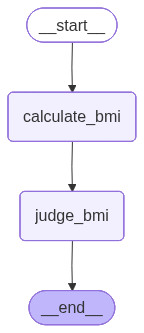

In [32]:
from IPython.display import Image
Image(wrokflow.get_graph().draw_mermaid_png())

__main__.BMIState